In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('D:/1kpsD9/Project/MINI/titanic/train.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Survival analysis

In [8]:
# overall survival rate

In [9]:
survival_rate = df['Survived'].mean()

In [10]:
survival_rate

0.3838383838383838

In [11]:
print(f"\nOverall survival rate: {survival_rate:.2%}\n")


Overall survival rate: 38.38%



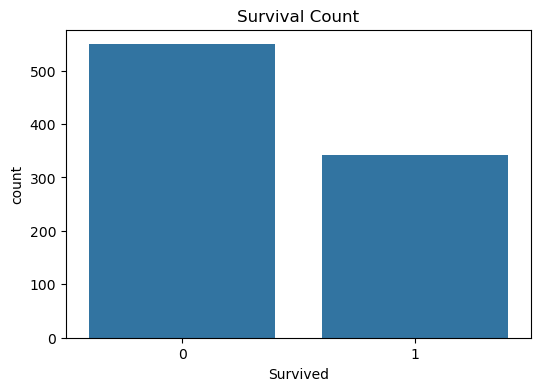

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

In [13]:
# Survival by Gender

In [14]:
gender_survival = df.groupby('Sex')['Survived'].mean()

In [15]:
gender_survival

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [16]:
print("Survival rate by gender:")
gender_survival

Survival rate by gender:


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

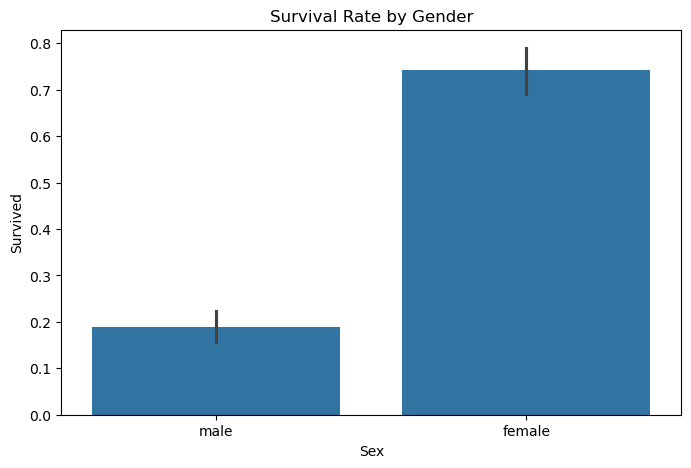

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

In [18]:
# Survival by Passenger Class

In [19]:
class_survival = df.groupby('Pclass')['Survived'].mean()
print("Survival rate by passenger class:")
print(class_survival)

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


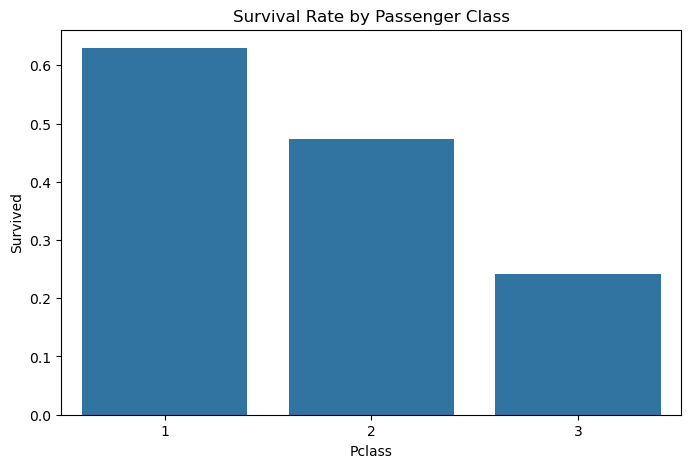

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None)
plt.title('Survival Rate by Passenger Class')
plt.show()

In [21]:
# Combined Gender and Class Analysis

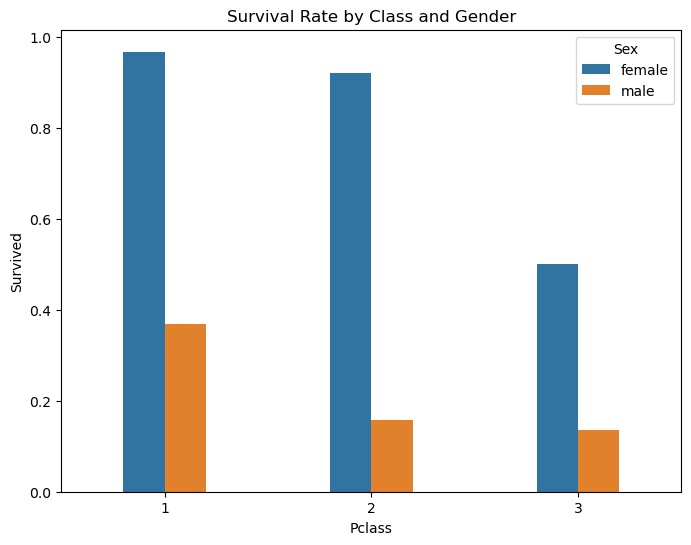

In [22]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, errorbar=None,width=0.4)
plt.title('Survival Rate by Class and Gender')
plt.show()

In [23]:
# Age Analysis

In [24]:
# Age Distribution

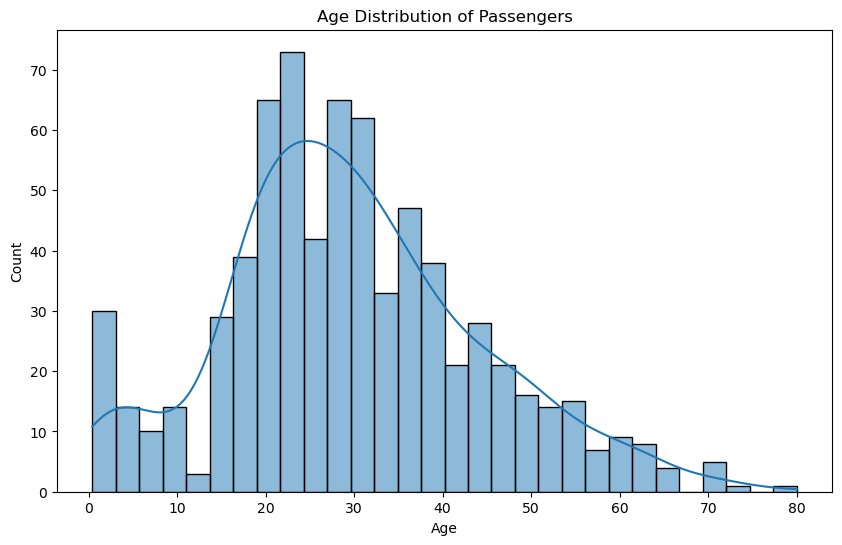

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.show()

In [26]:
# Survival by Age Groups

In [27]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 80], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

In [28]:
df['AgeGroup'].unique()

['Young Adult', 'Adult', NaN, 'Senior', 'Child', 'Teen']
Categories (5, object): ['Child' < 'Teen' < 'Young Adult' < 'Adult' < 'Senior']

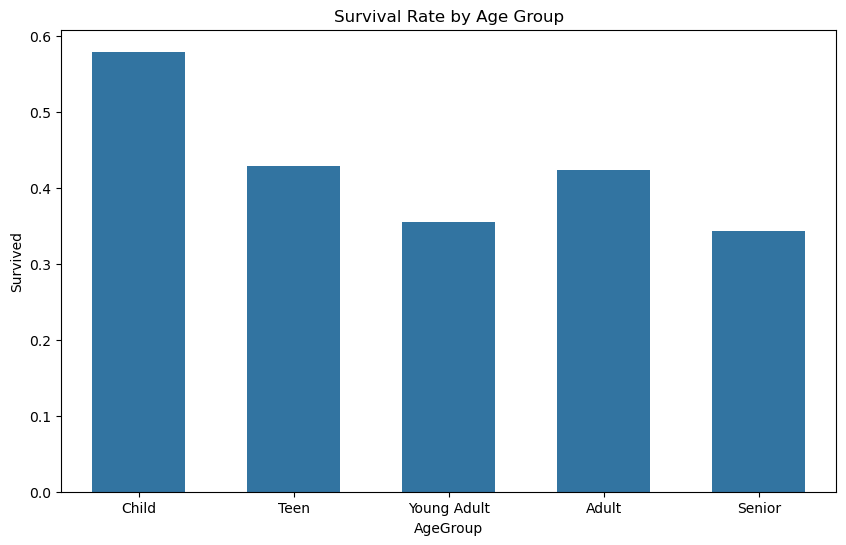

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Survived', data=df, errorbar=None,width=0.6)
plt.title('Survival Rate by Age Group')
plt.show()

In [30]:
# Age Distribution by Survival

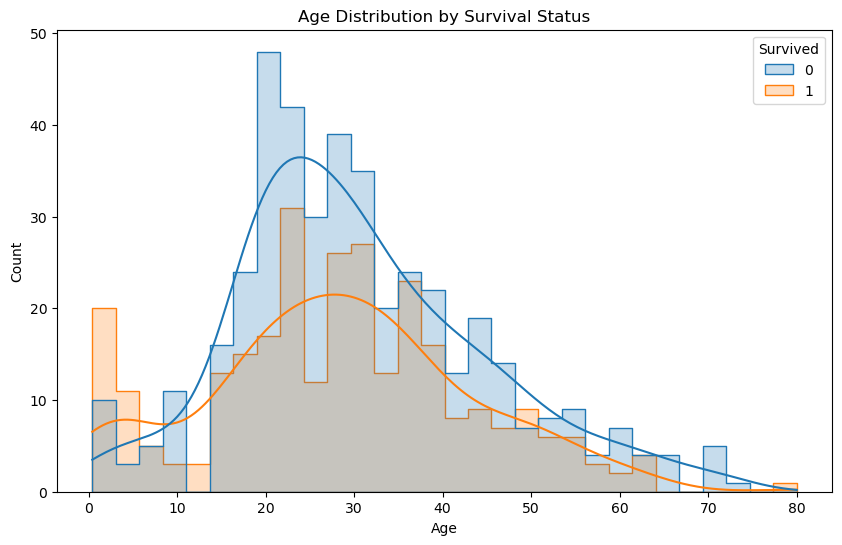

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Survived', element='step', bins=30, kde=True)
plt.title('Age Distribution by Survival Status')
plt.show()

In [32]:
# Fare Analysis

In [33]:
# Fare Distribution

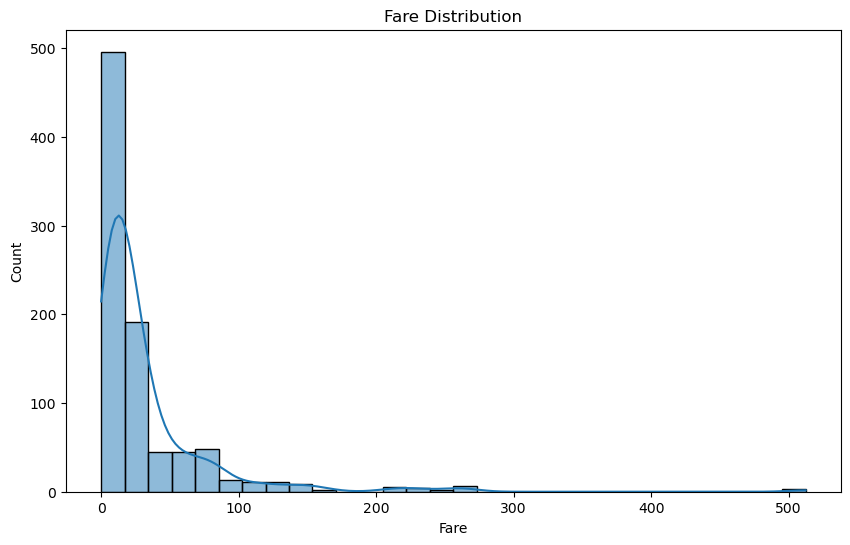

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.show()

In [35]:
# Survival by Fare Groups

In [36]:
df['FareGroup'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

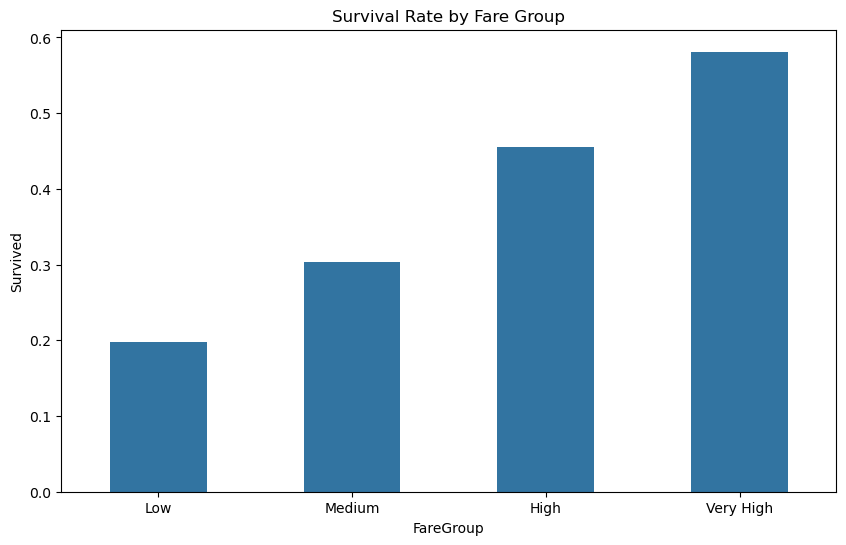

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(x='FareGroup', y='Survived', data=df, errorbar=None,width=0.5)
plt.title('Survival Rate by Fare Group')
plt.show()